In [ ]:
"""
Try to make a simple script for bottom T
"""

In [1]:
import xarray as xr
import sys

In [ ]:
#file_thetao = xr.open_dataset(str(sys.argv[0]))
#file_so = xr.open_dataset(str(sys.argv[1]))
#file_output = str(sys.argv[2])

In [10]:
### If I don't use sys
file_thetao = xr.open_dataset('/data/cburgard/thetao_test.nc')
file_so = xr.open_dataset('/data/cburgard/so_test.nc')
#file_T_all = xr.open_dataset(inputpath + 'opencav-presc02_18500101_18891231_1M_grid_T_varofint.nc')

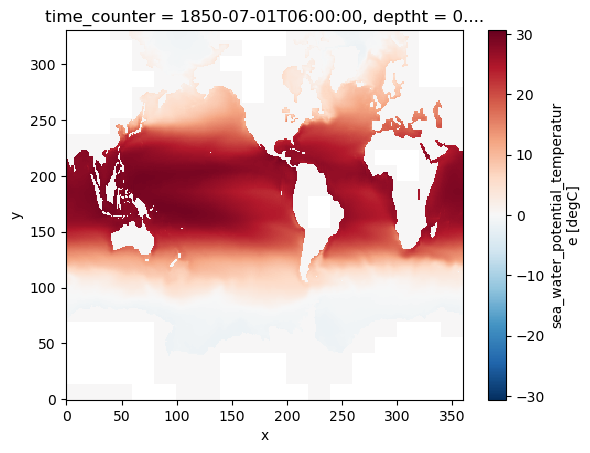

In [15]:
file_thetao['thetao'].isel(time_counter=0,deptht=0).plot()

In [8]:
mask_ocean = file_so['so'].isel(time_counter=0).drop('time_counter') > 0
vert_diff_minus_all = (mask_ocean - mask_ocean.shift(deptht=-1)).isel(deptht=range(1,len(mask_ocean.deptht)))
bot_depth_all = (mask_ocean.deptht * vert_diff_minus_all).where(vert_diff_minus_all > 0).sum('deptht').astype('float')

bot_depth_all_wo0 = bot_depth_all.where(bot_depth_all != 0, 5.057600e-01)
Tbot = file_thetao['thetao'].sel(deptht=bot_depth_all_wo0).where(bot_depth_all > 0)

In [9]:
Tbot.drop('deptht').to_dataset(name='T_bottom')

<xarray.Dataset>
Dimensions:       (time_counter: 40, y: 331, x: 360)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 1850-07-01T06:00:00 ... 1889-...
    nav_lon       (y, x) float32 73.5 74.5 75.5 76.5 ... -1.0 -1.0 -1.0 -1.0
    nav_lat       (y, x) float32 -84.21 -84.21 -84.21 -84.21 ... -1.0 -1.0 -1.0
Dimensions without coordinates: y, x
Data variables:
    T_bottom      (time_counter, y, x) float32 nan nan nan nan ... nan nan nan